# Projektaufgabe: Deskriptive Statistik und Visualisierungen

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

In [2]:
df = pd.read_csv("../data/Library_Usage.csv",low_memory=False, na_values="Null")
# drop missing values and sort by Age Range
df = df.dropna().sort_values('Age Range')

In [3]:
df.head()

,Patron Type Definition,Total Checkouts,Total Renewals,Age Range,Home Library Definition,Circulation Active Month,Circulation Active Year,Notice Preference Definition,Provided Email Address,Year Patron Registered,Within San Francisco County
377911,Juvenile,5,2,0 to 9 years,Ortega,May,2023.0,Phone,False,2023,True
368858,Juvenile,11,0,0 to 9 years,Excelsior,Mar,2024.0,Email,True,2021,True
368866,Juvenile,1,1,0 to 9 years,Excelsior,Jan,2022.0,Email,True,2021,True
377962,Juvenile,103,85,0 to 9 years,Ortega,Mar,2024.0,Email,True,2019,True
368868,Juvenile,7,5,0 to 9 years,Excelsior,Jul,2023.0,Email,True,2021,True


In [7]:
df['Total Checkouts'].describe()

count    406993.000000
mean        171.133902
std         549.093240
min           0.000000
25%           0.000000
50%          11.000000
75%          93.000000
max       39743.000000
Name: Total Checkouts, dtype: float64

In [9]:
# Spannweite Total Checkouts ursprünglich
df['Total Checkouts'].max() - df['Total Checkouts'].min()

39743

In [11]:
# Delete Outliers
q1 = df['Total Checkouts'].quantile(q=0.25)
q3 = df['Total Checkouts'].quantile(q=0.75)
iqr = q3 - q1

lower_range = q1 - 1.5 * iqr
upper_range = q3 + 1.5 * iqr

df_cleaned =  df[(df['Total Checkouts'] < upper_range ) & (df['Total Checkouts'] > lower_range)]

In [13]:
#Spannweite Total Checkouts cleaned
df_cleaned['Total Checkouts'].max() - df_cleaned['Total Checkouts'].min()

232

In [15]:
df_cleaned['Total Checkouts'].describe()

count    343903.000000
mean         29.345365
std          49.599914
min           0.000000
25%           0.000000
50%           5.000000
75%          34.000000
max         232.000000
Name: Total Checkouts, dtype: float64

## Wie viele Senioren und Kinder sind Kunden der San Francisco Public Library?

### Lösungsweg 1
Mit den Age Ranges, wie gegeben arbeiten ohne diese nach Senioren oder Kindern zu gruppieren.

In [19]:
df_cleaned['Age Range'].value_counts()

Age Range
25 to 34 years       84909
35 to 44 years       75042
10 to 19 years       43305
45 to 54 years       39070
65 to 74 years       22688
20 to 24 years       19794
0 to 9 years         18141
55 to 59 years       14633
75 years and over    13199
60 to 64 years       13122
Name: count, dtype: int64

[Text(0, 0, '18141'),
 Text(0, 0, '43305'),
 Text(0, 0, '19794'),
 Text(0, 0, '84909'),
 Text(0, 0, '75042'),
 Text(0, 0, '39070'),
 Text(0, 0, '14633'),
 Text(0, 0, '13122'),
 Text(0, 0, '22688'),
 Text(0, 0, '13199')]

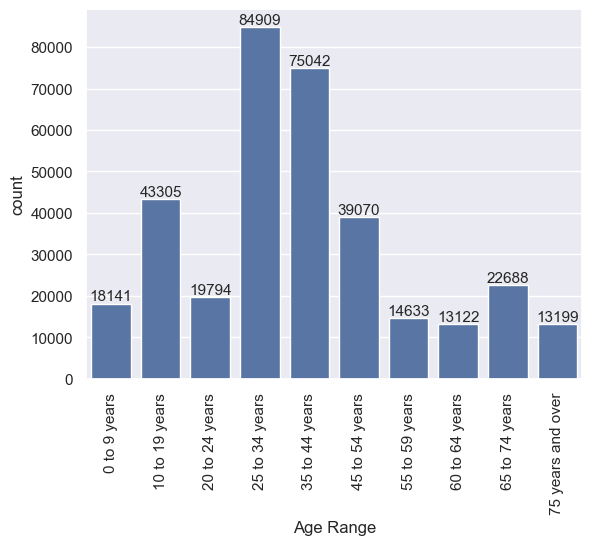

In [31]:
# Plot Age Range Distribution
fg = sns.countplot(x='Age Range', data=df_cleaned)
fg.tick_params(axis='x', labelrotation=90)
fg.bar_label(fg.containers[0], fontsize=11)

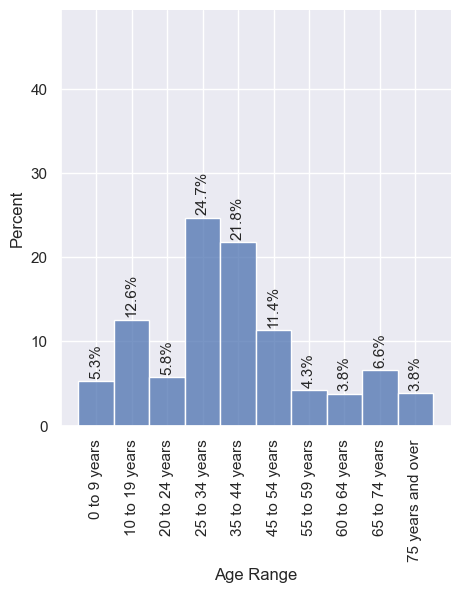

In [33]:
# Plot Age Range Distribution in percent
fg = sns.displot(x='Age Range', data=df_cleaned, stat='percent')

for ax in fg.axes.ravel():
    
    # add annotations
    for c in ax.containers:

        # custom label calculates percent and add an empty string so 0 value bars don't have a number
        labels = [f'{w:0.1f}%' if (w := v.get_height()) > 0 else '' for v in c]

        ax.bar_label(c, labels=labels, label_type='edge', fontsize=11, rotation=90, padding=2)
    
    ax.margins(y=1)



fg.tick_params(axis='x', labelrotation=90)

### Lösungsweg 2
Mit den Daten aus der Spalte 'Patron Type Definition' arbeiten. Um die Kinder zu zählen müsste man Juvenile und Teen kombinieren.

In [107]:
patron_type_count = df_cleaned['Patron Type Definition'].value_counts()

In [105]:
senior_count = patron_type_count['Senior']
children_count = patron_type_count['Juvenile'] + patron_type_count['Teen']
print(f'Children: {count_children} Senior: {senior_count}')

Children: 35243 Senior: 32906


### Lösungsweg 3
Die Daten aus Age Range zu Kategorien 'Child', 'Adult', 'Senior' zusammenfassen. Wäre sinnvoller, wenn das Konkrete Alter der Nutzer:innen angegeben wäre. So lassen sich nur alle 0 bis 19 Jährigen zur Kategorie 'Child' zusammenfassen. Kategorie 'Adult umfasst' alles zwischen 20 und 64 Jahren. Als Senioren gälten alle Nutzer über 65.

/var/folders/88/9blsh45918g8y3n5vl6vztxr0000gq/T/ipykernel_1457/1010079983.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Age Category'] = df_cleaned['Age Range']
/var/folders/88/9blsh45918g8y3n5vl6vztxr0000gq/T/ipykernel_1457/1010079983.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Age Category'] = df_cleaned['Age Category'].replace(age_mapping)


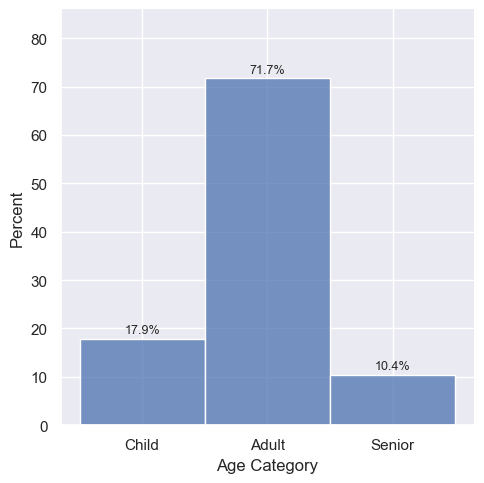

In [35]:
df_cleaned['Age Category'] = df_cleaned['Age Range']

age_mapping = {
        '0 to 9 years':'Child',
        '10 to 19 years':'Child',
        '20 to 24 years':'Adult',
        '25 to 34 years':'Adult',
        '35 to 44 years':'Adult',
        '45 to 54 years':'Adult',
        '55 to 59 years':'Adult',
        '60 to 64 years':'Adult',
        '65 to 74 years':'Senior',
        '75 years and over':'Senior'
    }

df_cleaned['Age Category'] = df_cleaned['Age Category'].replace(age_mapping)
fg = sns.displot(x='Age Category', data=df_cleaned, stat='percent')

for ax in fg.axes.ravel():
    
    # add annotations
    for c in ax.containers:

        # custom label calculates percent and add an empty string so 0 value bars don't have a number
        labels = [f'{w:0.1f}%' if (w := v.get_height()) > 0 else '' for v in c]

        ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=2)
    
    ax.margins(y=0.2)

In [37]:
df_cleaned['Age Category'].value_counts()

Age Category
Adult     246570
Child      61446
Senior     35887
Name: count, dtype: int64

## Wie viele Nutzer möchten per Mail informiert werden?

In [45]:
df_cleaned['Notice Preference Definition'].value_counts()

Notice Preference Definition
Email    316398
Phone     22655
Print      4850
Name: count, dtype: int64

In [47]:
df_cleaned['Notice Preference Definition'].value_counts(normalize=True)

Notice Preference Definition
Email    0.920021
Phone    0.065876
Print    0.014103
Name: proportion, dtype: float64

In [43]:
count_notice_pref = df['Notice Preference Definition'].value_counts()
mail_notice_pref = count_notice_pref['Email']
print(f'{mail_notice_pref} Nutzer möchten per Mail informiert werden.')

372805 Nutzer möchten per Mail informiert werden.


[Text(0, 0, '22655'), Text(0, 0, '316398'), Text(0, 0, '4850')]

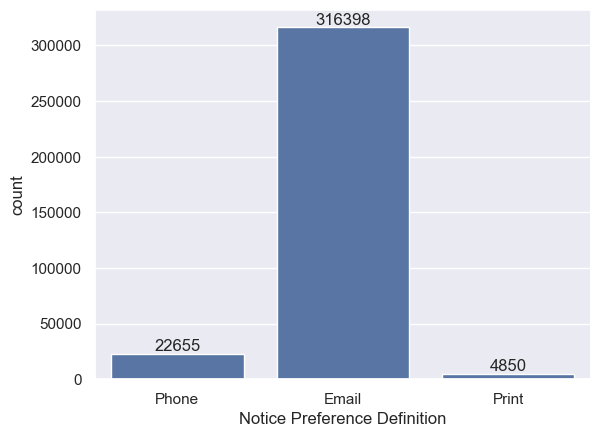

In [58]:
ax = sns.countplot(x='Notice Preference Definition', data=df_cleaned)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Notice Preference Definition', ylabel='percent'>

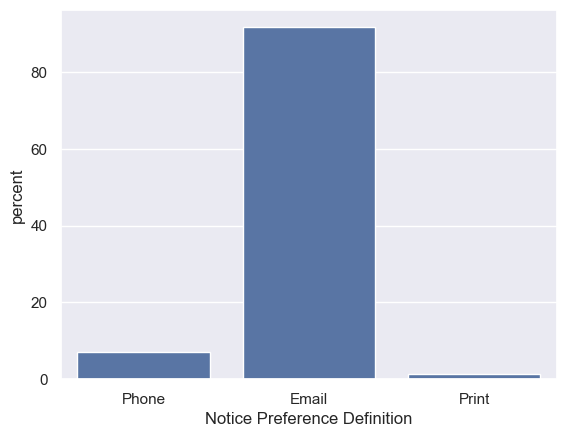

In [60]:
sns.countplot(x='Notice Preference Definition', data=df, stat='percent')

## In welcher Altersgruppe sind die meisten Nutzer, die per Email benachrichtigt werden möchten? 

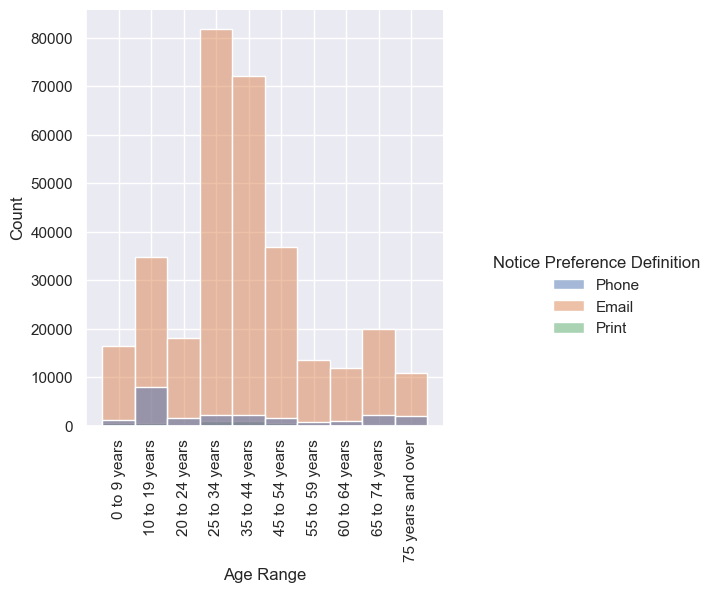

In [53]:
# Plot Age Range Distribution
fg = sns.displot(x='Age Range', data=df_cleaned, hue='Notice Preference Definition')
fg.tick_params(axis='x', labelrotation=90)

In [210]:
df_cleaned.groupby(['Age Range', 'Notice Preference Definition']).size().unstack(fill_value=0)

Notice Preference Definition,Email,Phone,Print
Age Range,,,
0 to 9 years,16458,1143,540
10 to 19 years,34807,7994,504
20 to 24 years,18060,1521,213
25 to 34 years,81759,2252,898
35 to 44 years,72033,2125,884
45 to 54 years,36926,1616,528
55 to 59 years,13535,873,225
60 to 64 years,11856,1028,238
65 to 74 years,20047,2180,461


## Wie viele Ausleihen werden im Mittel pro Altersgruppe und pro Jahr getätigt? Ist die Streuung zwischen den Gruppen gleich?

In [219]:
mean_checkouts_ar = round(df_cleaned.groupby(['Age Range'])['Total Checkouts'].mean(), 0)
df_mean_checkouts_ar = pd.DataFrame(mean_checkouts_ar)
df_mean_checkouts_ar = df_mean_checkouts_ar.rename(columns={'Total Checkouts': 'Mean Total Checkouts'})
df_mean_checkouts_ar

,Mean Total Checkouts
Age Range,
0 to 9 years,39.0
10 to 19 years,45.0
20 to 24 years,25.0
25 to 34 years,15.0
35 to 44 years,27.0
45 to 54 years,36.0
55 to 59 years,35.0
60 to 64 years,34.0
65 to 74 years,34.0
